In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
# Loading the COVID-19 dataset into df(DataFrame)
df=pd.read_csv('covid19.csv')
df.head(2)

C:\Users\Sandip phuyal\AppData\Local\Temp\ipykernel_26940\2326257196.py:2: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('covid19.csv')


,Unnamed: 0,index,continent,country,population,day,time,cases_new,cases_active,cases_critical,cases_recovered,cases_1M_pop,cases_total,deaths_new,deaths_1M_pop,deaths_total,tests_1M_pop,tests_total
0,0,0,Asia,Afghanistan,40418964.0,2022-03-17,2022-03-17T20:15:03+00:00,128.0,9698.0,1124.0,159569.0,4377.0,176918,NaN,189.0,7651.0,22496.0,909246.0
1,1,1,Asia,Afghanistan,40416563.0,2022-03-17,2022-03-17T08:00:04+00:00,126.0,9858.0,1124.0,159234.0,4373.0,176743,2.0,189.0,7651.0,22463.0,907896.0


# Data Cleaning

### Problems Found in the DataSet
- These column are not needed ( Unnamed: 0, index, time )
- Changing ['date'] column from 'text' to 'datetime' dtype.
- Changing ['deaths_new'] column from 'text' to 'numeric'
- There are some NaN in fixed columns ( country, continent, population ).
- A column Shift Error has occured in continent column causing some continents name to be population and populaiton to be NaN.[i.e 876, 1789,3395,5032]
- There are 229 countries in the dataset, since the official number is 195. We can drop the rest.
- In the continent, Austrilia continent is switched to Oceania since misunderstanding can be made because of Austrilia state and Austrilia continent in matplot.
- Removed all the same days Data and left one row for one day, Late time data of the day for accurate data
- 

In [3]:
# -Datatypes: we have day and time as text not time-series data[error]. 
#  we have deaths_new as a obj[text], make it numeric so u can do calculations on that columns.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232232 entries, 0 to 232231
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Unnamed: 0       232232 non-null  int64  
 1   index            232232 non-null  int64  
 2   continent        231157 non-null  object 
 3   country          232232 non-null  object 
 4   population       208220 non-null  float64
 5   day              232232 non-null  object 
 6   time             232232 non-null  object 
 7   cases_new        201745 non-null  float64
 8   cases_active     229459 non-null  float64
 9   cases_critical   187609 non-null  float64
 10  cases_recovered  228499 non-null  float64
 11  cases_1M_pop     232210 non-null  float64
 12  cases_total      232232 non-null  int64  
 13  deaths_new       150555 non-null  object 
 14  deaths_1M_pop    204718 non-null  float64
 15  deaths_total     226553 non-null  float64
 16  tests_1M_pop     204256 non-null  floa

In [4]:
# looks like Unnamed, index and time is redudant columns, i can remove them later...
df.head()

,Unnamed: 0,index,continent,country,population,day,time,cases_new,cases_active,cases_critical,cases_recovered,cases_1M_pop,cases_total,deaths_new,deaths_1M_pop,deaths_total,tests_1M_pop,tests_total
0,0,0,Asia,Afghanistan,40418964.0,2022-03-17,2022-03-17T20:15:03+00:00,128.0,9698.0,1124.0,159569.0,4377.0,176918,NaN,189.0,7651.0,22496.0,909246.0
1,1,1,Asia,Afghanistan,40416563.0,2022-03-17,2022-03-17T08:00:04+00:00,126.0,9858.0,1124.0,159234.0,4373.0,176743,2.0,189.0,7651.0,22463.0,907896.0
2,2,2,Asia,Afghanistan,40414161.0,2022-03-16,2022-03-16T08:00:04+00:00,108.0,10008.0,1124.0,158917.0,4369.0,176571,1.0,189.0,7646.0,22434.0,906639.0
3,3,3,Asia,Afghanistan,40411760.0,2022-03-15,2022-03-15T09:15:03+00:00,180.0,10257.0,1124.0,158507.0,4365.0,176409,2.0,189.0,7645.0,22410.0,905633.0
4,4,4,Asia,Afghanistan,40409359.0,2022-03-14,2022-03-14T09:15:03+00:00,118.0,10129.0,1124.0,158429.0,4360.0,176201,1.0,189.0,7643.0,22372.0,904055.0


In [5]:
# I want to narrow down the columns so i can focus on the dataFrame.
df_subset=df[['country','day','cases_new','cases_1M_pop','deaths_1M_pop','population','cases_critical']]
df_subset.head()

,country,day,cases_new,cases_1M_pop,deaths_1M_pop,population,cases_critical
0,Afghanistan,2022-03-17,128.0,4377.0,189.0,40418964.0,1124.0
1,Afghanistan,2022-03-17,126.0,4373.0,189.0,40416563.0,1124.0
2,Afghanistan,2022-03-16,108.0,4369.0,189.0,40414161.0,1124.0
3,Afghanistan,2022-03-15,180.0,4365.0,189.0,40411760.0,1124.0
4,Afghanistan,2022-03-14,118.0,4360.0,189.0,40409359.0,1124.0


In [6]:
#  Redudant columns, i removed 'time' because the data in this dataframe might not be consistent cuz 
#  COVID-19 data changes from days and weeks not hours[! the insights from the 'time[hours]' might not be reliable] 
df=df.drop(columns=['Unnamed: 0', 'index','time'])

In [7]:
# making 'day' column from text->datetime data and deaths_new from text to numeric
df['day']=pd.to_datetime(df['day'], errors='coerce')
df['deaths_new']=pd.to_numeric(df['deaths_new'], errors='coerce')

In [8]:
#continent is a constant value it shouldn't have nullvalues, can use ffill and bfill. 
df.isnull().sum()

continent           1075
country                0
population         24012
day                    0
cases_new          30487
cases_active        2773
cases_critical     44623
cases_recovered     3733
cases_1M_pop          22
cases_total            0
deaths_new         81681
deaths_1M_pop      27514
deaths_total        5679
tests_1M_pop       27976
tests_total        10660
dtype: int64

In [9]:
# Error found continent, missing Austrilia.
df['continent'].value_counts()

continent
Europe           59278
Asia             58350
North-America    52196
Africa           38559
South-America    17460
                 ...  
17607301             1
89174452             1
10833701             1
986088               1
29735785             1
Name: count, Length: 136, dtype: int64

In [10]:
# Error found [Column Shift Error] which caused some population to be NaN and continent to be population.
# looks like we need to make Australia/Oceania into 'Oceania' only so that it doesn't conflicit.
df.groupby('continent')['country'].unique()

continent
10091169                                                      [Sweden]
10127290                                                  [Azerbaijan]
10189909                                                      [Jordan]
10200387                                                    [Portugal]
106708                                                         [Aruba]
                                           ...                        
Australia/Oceania    [Australia, Fiji, French-Polynesia, New-Caledo...
Europe               [Albania, Andorra, Austria, Belarus, Belgium, ...
North-America        [Anguilla, Antigua-and-Barbuda, Aruba, Bahamas...
Oceania              [Australia, Cook-Islands, Fiji, French-Polynes...
South-America        [Argentina, Bolivia, Brazil, Chile, Colombia, ...
Name: country, Length: 136, dtype: object

In [11]:
row_iloc = df.iloc[876]

print("\nRow selected by .iloc[1]:")
print(row_iloc)


Row selected by .iloc[1]:
continent                     38807744
country                    Afghanistan
population                         NaN
day                2020-05-16 00:00:00
cases_new                        414.0
cases_active                    5155.0
cases_critical                     7.0
cases_recovered                  745.0
cases_1M_pop                     156.0
cases_total                       6053
deaths_new                        17.0
deaths_1M_pop                      NaN
deaths_total                     153.0
tests_1M_pop                       NaN
tests_total                    20854.0
Name: 876, dtype: object


In [12]:
# Finding out which continents are corrupted.
# we can find this by making the continent numeric, since the column[continent]- 
# -where error is in numeric we can ignore the string ones.
df.shape

(232232, 15)

In [13]:
# lets first find the columns before changing the dataset.
num_continent=pd.to_numeric(df['continent'],errors='coerce')
bad_data_mask = num_continent.notnull()
df_corruptedContinents=df[bad_data_mask]
df_corruptedContinents.head()

,continent,country,population,day,cases_new,cases_active,cases_critical,cases_recovered,cases_1M_pop,cases_total,deaths_new,deaths_1M_pop,deaths_total,tests_1M_pop,tests_total
876,38807744,Afghanistan,NaN,2020-05-16,414.0,5155.0,7.0,745.0,156.0,6053,17.0,NaN,153.0,NaN,20854.0
1789,2878189,Albania,NaN,2020-05-16,18.0,180.0,1.0,705.0,318.0,916,NaN,NaN,31.0,NaN,11458.0
3395,77249,Andorra,NaN,2020-05-15,NaN,116.0,3.0,596.0,9851.0,761,NaN,NaN,49.0,NaN,1673.0
5032,97824,Antigua-and-Barbuda,NaN,2020-05-26,NaN,3.0,1.0,19.0,256.0,25,NaN,NaN,3.0,NaN,183.0
6419,45141794,Argentina,NaN,2020-05-16,NaN,4284.0,170.0,2497.0,158.0,7134,NaN,NaN,353.0,NaN,96893.0


In [14]:
# solving the Column Shift Error
df = df[num_continent.isna()].copy()
df

,continent,country,population,day,cases_new,cases_active,cases_critical,cases_recovered,cases_1M_pop,cases_total,deaths_new,deaths_1M_pop,deaths_total,tests_1M_pop,tests_total
0,Asia,Afghanistan,40418964.0,2022-03-17,128.0,9698.0,1124.0,159569.0,4377.0,176918,NaN,189.0,7651.0,22496.0,909246.0
1,Asia,Afghanistan,40416563.0,2022-03-17,126.0,9858.0,1124.0,159234.0,4373.0,176743,2.0,189.0,7651.0,22463.0,907896.0
2,Asia,Afghanistan,40414161.0,2022-03-16,108.0,10008.0,1124.0,158917.0,4369.0,176571,1.0,189.0,7646.0,22434.0,906639.0
3,Asia,Afghanistan,40411760.0,2022-03-15,180.0,10257.0,1124.0,158507.0,4365.0,176409,2.0,189.0,7645.0,22410.0,905633.0
4,Asia,Afghanistan,40409359.0,2022-03-14,118.0,10129.0,1124.0,158429.0,4360.0,176201,1.0,189.0,7643.0,22372.0,904055.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232227,NaN,Zimbabwe,NaN,2020-04-02,1.0,7.0,NaN,NaN,0.5,8,NaN,NaN,1.0,NaN,NaN
232228,NaN,Zimbabwe,NaN,2020-03-31,2.0,6.0,NaN,NaN,0.5,7,NaN,NaN,1.0,NaN,NaN
232229,NaN,Zimbabwe,NaN,2020-03-28,2.0,4.0,NaN,NaN,0.3,5,NaN,NaN,1.0,NaN,NaN
232230,NaN,Zimbabwe,NaN,2020-03-27,NaN,2.0,NaN,NaN,0.2,3,1.0,NaN,1.0,NaN,NaN


In [15]:
# Changing the name of Austrilia continent to Oceania since austrilia name is both the state and the continent.
df.loc[df['continent']=='Austrilia/Oceania','continent']='Oceania'

In [16]:
# mapping
real_continents=['Asia','Europe','North-America','South-America','Africa','Oceania']
continent_map = (
    df[df['continent'].isin(real_continents)]
    .drop_duplicates('country')
    .set_index('country')['continent']
    .to_dict()
)

In [17]:
df['continent'] = df['country'].map(continent_map)

In [18]:
# Grouping the countries so the calculation of countries doesn't go outside of its individual country.
# filling up populaiton with ffill and bfill
df['population']=df.groupby('country')['population'].ffill().bfill()
df.head(3)

,continent,country,population,day,cases_new,cases_active,cases_critical,cases_recovered,cases_1M_pop,cases_total,deaths_new,deaths_1M_pop,deaths_total,tests_1M_pop,tests_total
0,Asia,Afghanistan,40418964.0,2022-03-17,128.0,9698.0,1124.0,159569.0,4377.0,176918,NaN,189.0,7651.0,22496.0,909246.0
1,Asia,Afghanistan,40416563.0,2022-03-17,126.0,9858.0,1124.0,159234.0,4373.0,176743,2.0,189.0,7651.0,22463.0,907896.0
2,Asia,Afghanistan,40414161.0,2022-03-16,108.0,10008.0,1124.0,158917.0,4369.0,176571,1.0,189.0,7646.0,22434.0,906639.0


In [19]:
# This drops rows that don't have a valid continent/population (like 'World' or errors)
df= df.dropna(subset=['continent', 'population'])

In [20]:
print(f"Dataset cleaned. New shape: {df.shape}")
print(df['continent'].value_counts())

Dataset cleaned. New shape: (232066, 15)
continent
Europe           59738
Asia             58469
North-America    52327
Africa           38793
South-America    17536
Oceania           5203
Name: count, dtype: int64


In [21]:
# just checking the countries. There is only 195 recogized countries officially and we have 222.
df['country'].nunique()

222

In [22]:
# listing all the countries to remove that are not inside of 195.
print(df[df['continent'] == 'Asia']['country'].unique())

['Afghanistan' 'Armenia' 'Azerbaijan' 'Bahrain' 'Bangladesh' 'Bhutan'
 'Brunei' 'Cambodia' 'China' 'Cyprus' 'Georgia' 'Hong-Kong' 'India'
 'Indonesia' 'Iran' 'Iraq' 'Israel' 'Japan' 'Jordan' 'Kazakhstan' 'Kuwait'
 'Kyrgyzstan' 'Laos' 'Lebanon' 'Macao' 'Malaysia' 'Maldives' 'Mongolia'
 'Myanmar' 'Nepal' 'Oman' 'Pakistan' 'Palestine' 'Philippines' 'Qatar'
 'S-Korea' 'Saudi-Arabia' 'Singapore' 'Sri-Lanka' 'Syria' 'Taiwan'
 'Tajikistan' 'Thailand' 'Timor-Leste' 'Turkey' 'UAE' 'Uzbekistan'
 'Vietnam' 'Yemen']


In [23]:
print(df[df['continent'] == 'Europe']['country'].unique())

['Albania' 'Andorra' 'Austria' 'Belarus' 'Belgium'
 'Bosnia-and-Herzegovina' 'Bulgaria' 'Channel-Islands' 'Croatia' 'Czechia'
 'Denmark' 'Estonia' 'Faeroe-Islands' 'Finland' 'France' 'Germany'
 'Gibraltar' 'Greece' 'Hungary' 'Iceland' 'Ireland' 'Isle-of-Man' 'Italy'
 'Latvia' 'Liechtenstein' 'Lithuania' 'Luxembourg' 'Malta' 'Moldova'
 'Monaco' 'Montenegro' 'Netherlands' 'North-Macedonia' 'Norway' 'Poland'
 'Portugal' 'Romania' 'Russia' 'San-Marino' 'Serbia' 'Slovakia' 'Slovenia'
 'Spain' 'Sweden' 'Switzerland' 'UK' 'Ukraine' 'Vatican-City']


In [24]:
print(df[df['continent'] == 'North-America']['country'].unique())

['Anguilla' 'Antigua-and-Barbuda' 'Aruba' 'Bahamas' 'Barbados' 'Belize'
 'Bermuda' 'British-Virgin-Islands' 'Canada' 'Caribbean-Netherlands'
 'Cayman-Islands' 'Costa-Rica' 'Cuba' 'Dominica' 'Dominican-Republic'
 'El-Salvador' 'Greenland' 'Grenada' 'Guadeloupe' 'Guatemala' 'Haiti'
 'Honduras' 'Jamaica' 'Martinique' 'Mexico' 'Montserrat' 'Nicaragua'
 'Panama' 'Saint-Kitts-and-Nevis' 'Saint-Lucia' 'Saint-Martin'
 'Saint-Pierre-Miquelon' 'Sint-Maarten' 'St-Barth' 'St-Vincent-Grenadines'
 'Trinidad-and-Tobago' 'Turks-and-Caicos' 'USA']


In [25]:
print(df[df['continent'] == 'South-America']['country'].unique())

['Argentina' 'Bolivia' 'Brazil' 'Chile' 'Colombia' 'Ecuador'
 'Falkland-Islands' 'French-Guiana' 'Guyana' 'Paraguay' 'Peru' 'Suriname'
 'Uruguay' 'Venezuela']


In [26]:
print(df[df['continent'] == 'Africa']['country'].unique())

['Algeria' 'Angola' 'Benin' 'Botswana' 'Burkina-Faso' 'Burundi'
 'Cabo-Verde' 'Cameroon' 'CAR' 'Chad' 'Comoros' 'Congo' 'Djibouti' 'DRC'
 'Egypt' 'Equatorial-Guinea' 'Eritrea' 'Eswatini' 'Ethiopia' 'Gabon'
 'Gambia' 'Ghana' 'Guinea' 'Guinea-Bissau' 'Ivory-Coast' 'Kenya' 'Lesotho'
 'Liberia' 'Libya' 'Madagascar' 'Malawi' 'Mali' 'Mauritania' 'Mauritius'
 'Mayotte' 'Morocco' 'Mozambique' 'Namibia' 'Niger' 'Nigeria' 'Rwanda'
 'Saint-Helena' 'Sao-Tome-and-Principe' 'Senegal' 'Seychelles'
 'Sierra-Leone' 'Somalia' 'South-Africa' 'South-Sudan' 'Sudan' 'Tanzania'
 'Togo' 'Tunisia' 'Uganda' 'Western-Sahara' 'Zambia' 'Zimbabwe']


In [27]:
print(df[df['continent'] == 'Oceania']['country'].unique())

['Australia' 'Cook-Islands' 'Fiji' 'French-Polynesia' 'Kiribati'
 'Marshall-Islands' 'Micronesia' 'New-Caledonia' 'New-Zealand' 'Palau'
 'Papua-New-Guinea' 'Samoa' 'Solomon-Islands' 'Tonga' 'Vanuatu'
 'Wallis-and-Futuna']


In [28]:
# listing all the territories that are not official
territories_to_remove = [
    'Hong-Kong','Channel-Islands', 'Faeroe-Islands', 
    'Gibraltar', 'Isle-of-Man', 'Anguilla', 'Aruba', 
    'British-Virgin-Islands', 'Caribbean-Netherlands', 'Cayman-Islands',
    'Guadeloupe', 'Martinique', 'Montserrat', 'Saint-Martin', 
    'Saint-Pierre-Miquelon', 'Sint-Maarten', 'St-Barth', 'Turks-and-Caicos', 
    'Mayotte', 'Saint-Helena', 'Western-Sahara', 'Falkland-Islands', 
    'French-Guiana', 'Cook-Islands', 'French-Polynesia', 'New-Caledonia', 
    'Wallis-and-Futuna'
]

In [29]:
ships_and_misc = [
    'Diamond-Princess','Diamond-Princess-',
    'MS-Zaandam','MS-Zaandam-',
    'Guam','Puerto-Rico','US-Virgin-Islands',
    'World'
]
df = df[~df['country'].isin(territories_to_remove + ships_and_misc)].copy()
print(f"Final Count of Countries: {df['country'].nunique()}")

Final Count of Countries: 195


In [30]:
# sorting countries
df = df.sort_values(['country', 'day']).reset_index(drop=True)

In [31]:
print("Final shape:", df.shape)
print("Unique countries:", df['country'].nunique())
print(df['continent'].value_counts())

Final shape: (217436, 15)
Unique countries: 195
continent
Asia             57525
Europe           56413
North-America    45970
Africa           37848
South-America    16119
Oceania           3561
Name: count, dtype: int64


In [32]:
# Droping all the duplicates rows
df= (
    df
    .drop_duplicates(subset=['country', 'day'], keep='last')
    .reset_index(drop=True)
)

In [33]:
df.isnull().sum()

continent              0
country                0
population             0
day                    0
cases_new           9631
cases_active        1490
cases_critical     29313
cases_recovered     2101
cases_1M_pop           0
cases_total            0
deaths_new         41255
deaths_1M_pop      12618
deaths_total        3430
tests_1M_pop       13815
tests_total         6295
dtype: int64

In [34]:
df

,continent,country,population,day,cases_new,cases_active,cases_critical,cases_recovered,cases_1M_pop,cases_total,deaths_new,deaths_1M_pop,deaths_total,tests_1M_pop,tests_total
0,Asia,Afghanistan,38848565.0,2020-03-22,10.0,33.0,NaN,1.0,0.9,34,NaN,NaN,NaN,NaN,NaN
1,Asia,Afghanistan,38848565.0,2020-03-24,16.0,38.0,NaN,1.0,1.0,40,1.0,NaN,1.0,NaN,NaN
2,Asia,Afghanistan,38848565.0,2020-03-25,34.0,72.0,NaN,1.0,2.0,74,NaN,NaN,1.0,NaN,NaN
3,Asia,Afghanistan,38848565.0,2020-03-26,10.0,80.0,NaN,2.0,2.0,84,1.0,NaN,2.0,NaN,NaN
4,Asia,Afghanistan,38848565.0,2020-03-27,10.0,88.0,NaN,2.0,2.0,94,2.0,NaN,4.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115738,Africa,Zimbabwe,15227999.0,2022-03-13,NaN,5219.0,12.0,231438.0,15896.0,242069,NaN,355.0,5412.0,139800.0,2128873.0
115739,Africa,Zimbabwe,15228590.0,2022-03-14,158.0,4896.0,12.0,232205.0,15925.0,242515,NaN,356.0,5414.0,140127.0,2133936.0
115740,Africa,Zimbabwe,15229182.0,2022-03-15,158.0,4896.0,12.0,232205.0,15924.0,242515,NaN,356.0,5414.0,140122.0,2133936.0
115741,Africa,Zimbabwe,15229773.0,2022-03-16,394.0,5068.0,12.0,232425.0,15950.0,242909,2.0,356.0,5416.0,140331.0,2137216.0


In [35]:
df.columns

Index(['continent', 'country', 'population', 'day', 'cases_new',
       'cases_active', 'cases_critical', 'cases_recovered', 'cases_1M_pop',
       'cases_total', 'deaths_new', 'deaths_1M_pop', 'deaths_total',
       'tests_1M_pop', 'tests_total'],
      dtype='object')

### COVID-19 Overview

COVID-19 is an infectious disease caused by the SARS-CoV-2 virus. 
It spreads primarily through respiratory droplets and caused a global pandemic 
affecting nearly every country, overwhelming healthcare systems and causing 
millions of deaths worldwide.


In [36]:
total_cases_global = df['cases_total'].max()
total_deaths_global = df['deaths_total'].max()

print(f"Total COVID-19 Cases Globally: {total_cases_global:,}")
print(f"Total COVID-19 Deaths Globally: {total_deaths_global:,}")


Total COVID-19 Cases Globally: 81,278,968
Total COVID-19 Deaths Globally: 994,710.0


In [37]:
global_daily = (
    df.groupby('day')[['cases_total', 'deaths_total']]
    .sum()
    .reset_index()
)


In [38]:
peak_cases_row = global_daily.loc[global_daily['cases_total'].idxmax()]
peak_deaths_row = global_daily.loc[global_daily['deaths_total'].idxmax()]


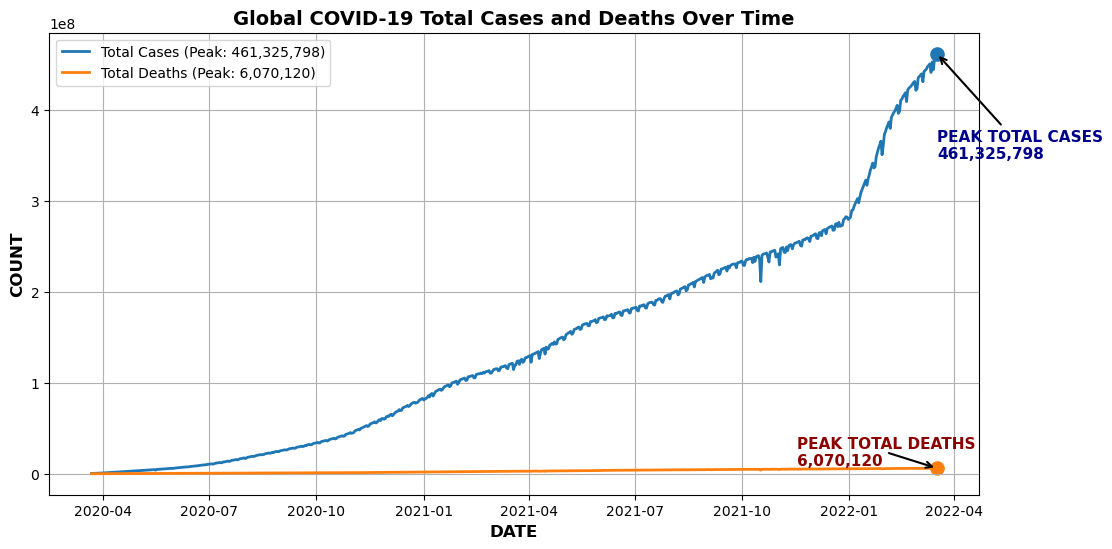

In [39]:
plt.figure(figsize=(12,6))

# Main lines
plt.plot(
    global_daily['day'],
    global_daily['cases_total'],
    label=f"Total Cases (Peak: {int(peak_cases_row['cases_total']):,})",
    linewidth=2
)

plt.plot(
    global_daily['day'],
    global_daily['deaths_total'],
    label=f"Total Deaths (Peak: {int(peak_deaths_row['deaths_total']):,})",
    linewidth=2
)

# Mark peak points
plt.scatter(
    peak_cases_row['day'],
    peak_cases_row['cases_total'],
    s=90
)

plt.scatter(
    peak_deaths_row['day'],
    peak_deaths_row['deaths_total'],
    s=90
)

# Annotate Peak Total Cases
plt.annotate(
    f"PEAK TOTAL CASES\n{int(peak_cases_row['cases_total']):,}",
    xy=(peak_cases_row['day'], peak_cases_row['cases_total']),
    xytext=(peak_cases_row['day'], peak_cases_row['cases_total'] * 0.75),
    arrowprops=dict(arrowstyle='->', linewidth=1.5),
    fontsize=11,
    fontweight='bold',
    color='darkblue'
)

# Annotate Peak Total Deaths (angled & offset)
plt.annotate(
    f"PEAK TOTAL DEATHS\n{int(peak_deaths_row['deaths_total']):,}",
    xy=(peak_deaths_row['day'], peak_deaths_row['deaths_total']),
    xytext=(peak_deaths_row['day'] - pd.Timedelta(days=120),
            peak_deaths_row['deaths_total'] * 1.5), #2.5
    arrowprops=dict(arrowstyle='->', linewidth=1.5),
    fontsize=11,
    fontweight='bold',
    color='darkred'
)

# Titles and labels
plt.title(
    'Global COVID-19 Total Cases and Deaths Over Time',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'DATE',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'COUNT',
    fontsize=12,
    fontweight='bold'
)

# Grid & legend
plt.legend(fontsize=10)
plt.grid(True)

plt.show()


In [40]:
df_2020 = df[df['day'].dt.year == 2020].copy()


In [41]:
china_2020 = df_2020[df_2020['country'] == 'China']


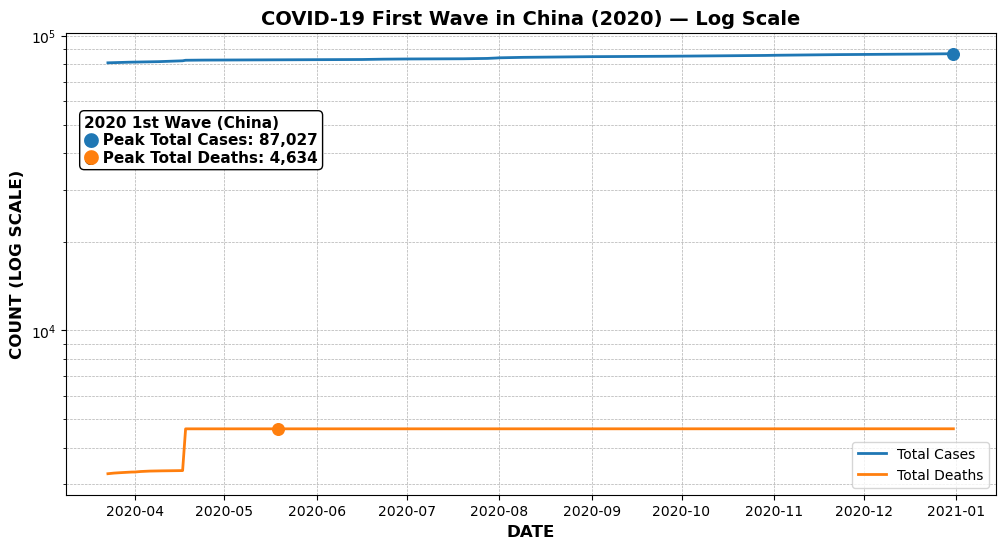

In [42]:
# Peak values and locations
peak_cases_value = china_2020['cases_total'].max()
peak_cases_date = china_2020.loc[china_2020['cases_total'].idxmax(), 'day']

peak_deaths_value = china_2020['deaths_total'].max()
peak_deaths_date = china_2020.loc[china_2020['deaths_total'].idxmax(), 'day']

plt.figure(figsize=(12,6))

# Lines
plt.plot(
    china_2020['day'],
    china_2020['cases_total'],
    label=f"Total Cases",
    linewidth=2
)

plt.plot(
    china_2020['day'],
    china_2020['deaths_total'],
    label=f"Total Deaths",
    linewidth=2
)

# Peak dots (no arrows, no text)
plt.scatter(
    peak_cases_date,
    peak_cases_value,
    s=70,
    zorder=5
)

plt.scatter(
    peak_deaths_date,
    peak_deaths_value,
    s=70,
    zorder=5
)

# Log scale
plt.yscale('log')

plt.title(
    'COVID-19 First Wave in China (2020) — Log Scale',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('DATE', fontsize=12, fontweight='bold')
plt.ylabel('COUNT (LOG SCALE)', fontsize=12, fontweight='bold')

# Summary box with colored dots
summary_text = (
    "2020 1st Wave (China)\n"
    f"● Peak Total Cases: {int(peak_cases_value):,}\n"
    f"● Peak Total Deaths: {int(peak_deaths_value):,}"
)

plt.text(
    0.02,
    0.72,
    summary_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    fontweight='bold',
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='black')
)

# Color the dots inside summary box
plt.text(0.019, 0.756, "●", transform=plt.gca().transAxes, color='tab:blue', fontsize=14)
plt.text(0.019, 0.720, "●", transform=plt.gca().transAxes, color='tab:orange', fontsize=14)

plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()


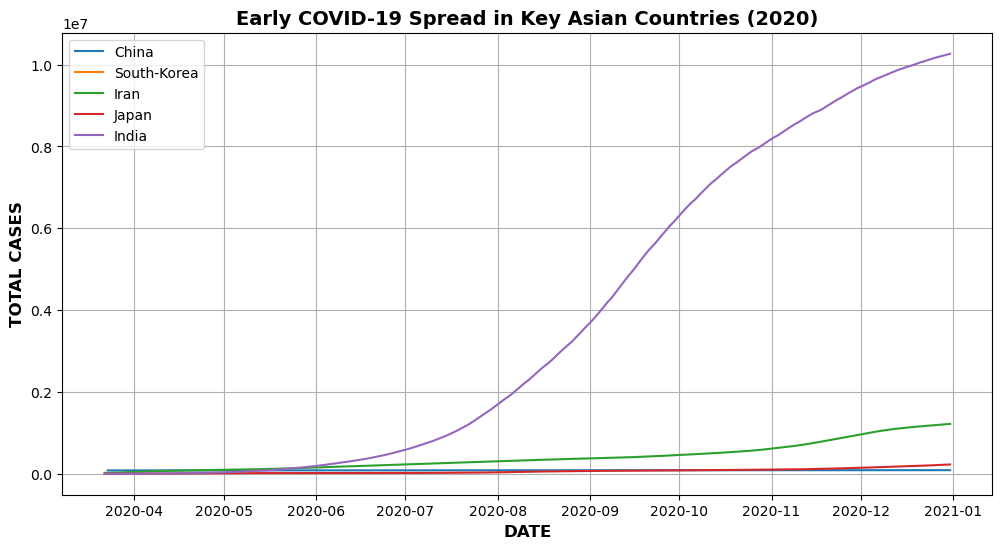

In [43]:
key_asia_countries = ['China', 'South-Korea', 'Iran', 'Japan', 'India']

plt.figure(figsize=(12,6))

for country in key_asia_countries:
    subset = df_2020[df_2020['country'] == country]
    plt.plot(subset['day'], subset['cases_total'], label=country)

plt.title(
    'Early COVID-19 Spread in Key Asian Countries (2020)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('DATE', fontsize=12, fontweight='bold')
plt.ylabel('TOTAL CASES', fontsize=12, fontweight='bold')

plt.legend()
plt.grid(True)
plt.show()


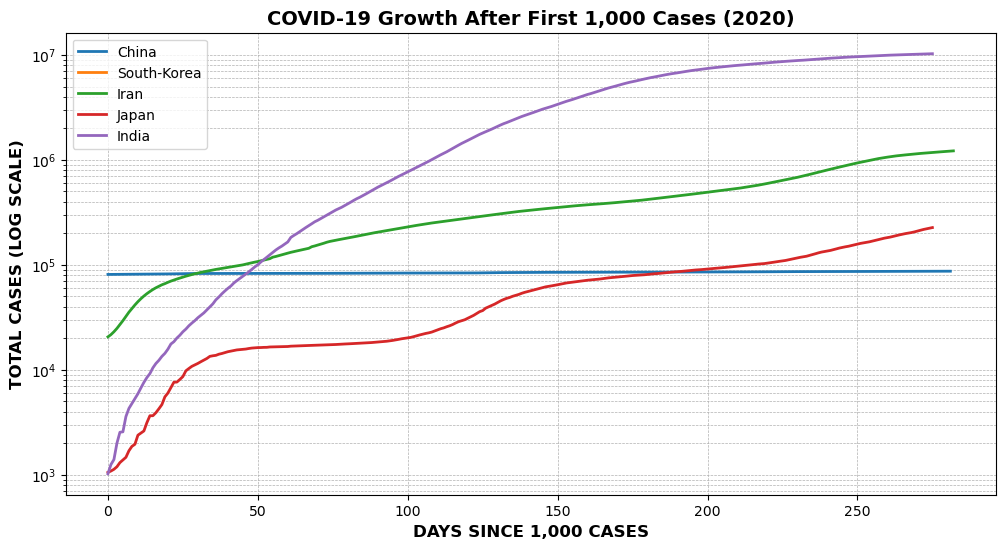

In [44]:
plt.figure(figsize=(12,6))

for country in key_asia_countries:
    subset = df_2020[df_2020['country'] == country].copy()
    
    # Start counting after 1,000 cases
    subset = subset[subset['cases_total'] >= 1000]
    subset['days_since_1000'] = range(len(subset))
    
    plt.plot(
        subset['days_since_1000'],
        subset['cases_total'],
        label=country,
        linewidth=2
    )

plt.yscale('log')
plt.title(
    'COVID-19 Growth After First 1,000 Cases (2020)',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('DAYS SINCE 1,000 CASES', fontsize=12, fontweight='bold')
plt.ylabel('TOTAL CASES (LOG SCALE)', fontsize=12, fontweight='bold')

plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()
